# Email Spam Detection using Machine Learning

This notebook demonstrates the process of building a machine learning classification model to detect whether an email is **Spam** or **Ham (Not Spam)**. The project includes data preprocessing, text vectorization, model training, evaluation, visualization, and model saving.

## Step 1: Upload and Load the Dataset

The email spam dataset is uploaded from the local system and loaded into a Pandas DataFrame. This allows us to access and analyze the data using Python.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving email spam.xlsx to email spam (2).xlsx


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_excel("email spam.xlsx")
df.head()

,email,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
import pandas as pd

## Step 2: Select Relevant Columns

Only the required columns (**email** and **message**) are selected from the dataset. This removes unnecessary information and keeps the dataset focused on the classification task.

In [ ]:
df = df[['email', 'message']]
df.head()

,email,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 3: Encode the Target Variable

The target column is converted into numerical values. Spam emails are encoded as **1**, while Ham (non-spam) emails are encoded as **0**. Machine learning models require numerical target values for training.

In [ ]:
df['email'] = df['email'].map({'spam': 1, 'ham': 0})

## Step 4: Check for Missing Values

The dataset is examined for missing values to ensure that all records are complete before training the machine learning model.

In [ ]:
print(df.head())
print(df.isnull().sum())

   email                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
email      0
message    0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df['message'].astype(str)
y = df['email']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

## Step 5: Split the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets using an 80:20 ratio. The training data is used to build the model, while the testing data is used to evaluate its performance on unseen data.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9668161434977578
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



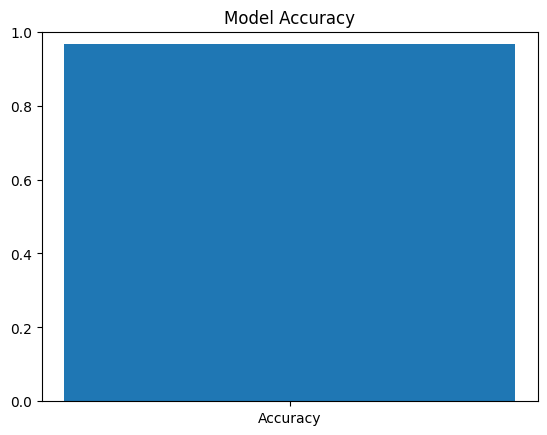

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

plt.bar(["Accuracy"], [acc])
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.show()

## Step 7: Train the Classification Model

A Multinomial Naive Bayes classifier is used to train the model. This algorithm is widely used for text classification tasks such as spam email detection because it is fast and performs well on textual data.

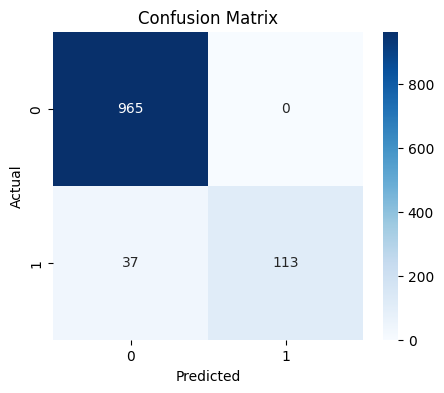

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

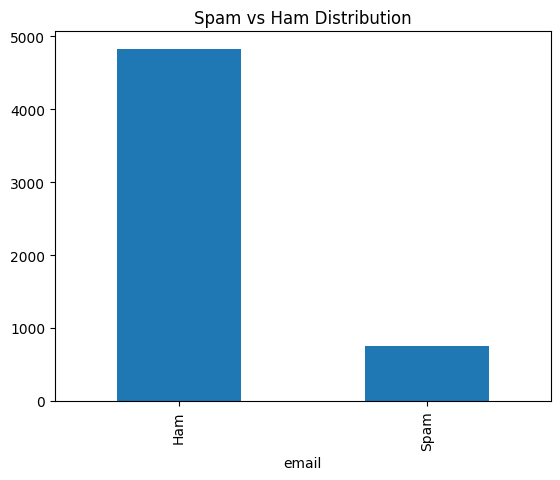

In [ ]:
df['email'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.xticks([0,1], ["Ham", "Spam"])
plt.show()

## Step 8: Evaluate Model Performance

The trained model is tested using the unseen test dataset. Performance is evaluated using Accuracy, Precision, Recall, and F1-Score to measure how effectively the model distinguishes spam emails from legitimate emails

In [ ]:
train_pred = model.predict(X_train_vec)
train_acc = accuracy_score(y_train, train_pred)
print("Train Accuracy:", train_acc)

Train Accuracy: 0.9838456360780794


In [ ]:
test_pred = model.predict(X_test_vec)
test_acc = accuracy_score(y_test, test_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9668161434977578


In [ ]:
overfitting_gap = train_acc - test_acc
print("Overfitting Gap:", overfitting_gap)

Overfitting Gap: 0.017029492580321604


In [ ]:
def predict_email(text):
    text_vec = vectorizer.transform([text])
    result = model.predict(text_vec)

    if result[0] == 1:
        print("Spam Email")
    else:
        print(" Ham Email")

predict_email("Congratulations! You won a free iPhone click now")

Spam Email


In [ ]:
import joblib

In [ ]:
joblib.dump(model, "spam_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("Model saved successfully ")

Model saved successfully 


In [ ]:
from google.colab import files

files.download("spam_model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>